# Bank Stock Price Forecasting — XGBoost + GRU + BiLSTM + CNN-LSTM

This notebook trains **four different models** on the same time-series forecasting
task (next-day **Close** price) for each bank in the dataset, so you can directly
compare how each architecture predicts:

1. XGBoost — gradient-boosted trees on engineered lag/rolling features
2. GRU — Gated Recurrent Unit 
3. BiLSTM — Bidirectional LSTM 
4. CNN-LSTM — 1D-CNN feature extractor feeding an LSTM

## Setup & Imports

In [ ]:

!pip install -q xgboost torch scikit-learn matplotlib pandas numpy


In [ ]:
import os
import zipfile
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## Configuration

In [ ]:
DATA_DIR = "."

FILES = {
    "combined": os.path.join(DATA_DIR, "all_bank_stock_data.csv"),
    "Barclays": os.path.join(DATA_DIR, "barclays_bank_stock_data.csv"),
    "Goldman Sachs": os.path.join(DATA_DIR, "gs_bank_stock_data.csv"),
    "Lloyds": os.path.join(DATA_DIR, "lloyds_bank_stock_data.csv"),
}

FEATURES = ["Open", "High", "Low", "Close", "Volume"]
TARGET = "Close"

LOOKBACK = 60
HORIZON = 1
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

BATCH_SIZE = 32
EPOCHS = 40
PATIENCE = 8
LR = 1e-3
HIDDEN = 64

OUTPUT_DIR = "trained_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load & Clean Data


In [ ]:
def load_bank_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df = df.dropna(subset=["Date"]).copy()
    df["Date"] = pd.to_datetime(df["Date"])
    for c in ["Open", "High", "Low", "Close", "Volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

combined = load_bank_csv(FILES["combined"])
combined = combined.sort_values(["Bank", "Date"]).reset_index(drop=True)
combined = combined.dropna(subset=FEATURES)

BANKS = sorted(combined["Bank"].unique().tolist())
print("Banks found:", BANKS)
print(combined.groupby("Bank")["Date"].agg(["min", "max", "count"]))
combined.head()

Banks found: ['Barclays', 'Goldman Sachs', 'Lloyds']
                     min        max  count
Bank                                      
Barclays      2015-01-02 2026-05-29   2880
Goldman Sachs 2015-01-02 2026-05-29   2868
Lloyds        2015-01-02 2026-05-29   2881


,Date,Bank,Open,High,Low,Close,Volume
0,2015-01-02,Barclays,241.440950,244.830304,240.792993,242.387970,20219711
1,2015-01-05,Barclays,241.540745,242.388072,233.466121,233.964554,39050852
2,2015-01-06,Barclays,233.316545,235.110908,229.528451,229.628143,37573308
3,2015-01-07,Barclays,231.372680,232.728419,229.428778,229.877380,37219841
4,2015-01-08,Barclays,233.565822,237.603135,230.824439,236.307205,41082776


In [ ]:
for bank, key in [("Barclays", "Barclays"), ("Goldman Sachs", "Goldman Sachs"), ("Lloyds", "Lloyds")]:
    indiv = load_bank_csv(FILES[key]).sort_values("Date").reset_index(drop=True)
    comb_bank = combined[combined["Bank"] == bank].sort_values("Date").reset_index(drop=True)
    merged = pd.merge(indiv[["Date", "Close"]], comb_bank[["Date", "Close"]],
                       on="Date", suffixes=("_indiv", "_combined"))
    diff = (merged["Close_indiv"] - merged["Close_combined"]).abs().max()
    print(f"{bank}: {len(merged)} overlapping rows, max Close difference = {diff:.6f}")

Barclays: 2880 overlapping rows, max Close difference = 0.000000
Goldman Sachs: 2868 overlapping rows, max Close difference = 0.000000
Lloyds: 2881 overlapping rows, max Close difference = 0.000000


## Exploratory Plot — Close Price per Bank

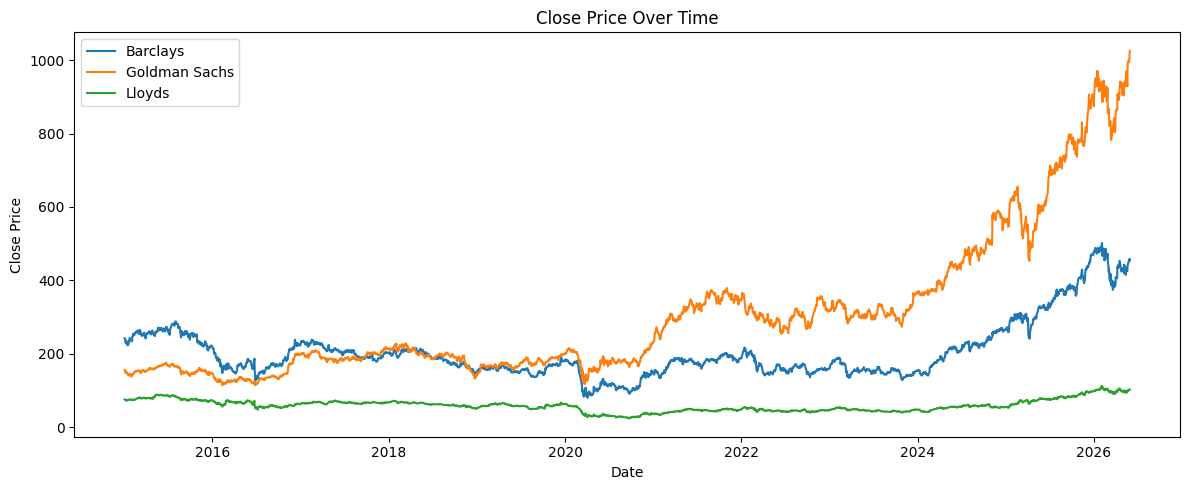

In [ ]:
plt.figure(figsize=(12, 5))
for bank in BANKS:
    bdf = combined[combined["Bank"] == bank]
    plt.plot(bdf["Date"], bdf["Close"], label=bank)
plt.title("Close Price Over Time")
plt.xlabel("Date"); plt.ylabel("Close Price")
plt.legend(); plt.tight_layout(); plt.show()

## Preprocessing Utilities

Two data representations are built per bank:

* Sequence windows (X: [samples, LOOKBACK, features]) for the neural nets
* Tabular lag/rolling features for XGBoost





Scaling and the train/val/test split are always time-ordered (no shuffling
across time, no leakage from the future into training).


In [ ]:
def time_split_index(n, train_frac, val_frac):
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return train_end, val_end


def make_sequence_dataset(bdf, features, target, lookback):
    """Returns scaled sequence X/y splits plus the fitted scalers
    (feature_scaler for X, target_scaler for inverse-transforming y)."""
    n = len(bdf)
    train_end, val_end = time_split_index(n, TRAIN_FRAC, VAL_FRAC)

    feature_scaler = MinMaxScaler()
    feature_scaler.fit(bdf.loc[:train_end - 1, features].values)
    scaled_features = feature_scaler.transform(bdf[features].values)

    target_scaler = MinMaxScaler()
    target_scaler.fit(bdf.loc[:train_end - 1, [target]].values)
    scaled_target = target_scaler.transform(bdf[[target]].values).flatten()

    X, y = [], []
    for i in range(lookback, n):
        X.append(scaled_features[i - lookback:i])
        y.append(scaled_target[i])
    X, y = np.array(X), np.array(y)

    offset = lookback
    idx = np.arange(len(X))
    train_mask = idx < (train_end - offset)
    val_mask = (idx >= (train_end - offset)) & (idx < (val_end - offset))
    test_mask = idx >= (val_end - offset)

    splits = {
        "X_train": X[train_mask], "y_train": y[train_mask],
        "X_val": X[val_mask], "y_val": y[val_mask],
        "X_test": X[test_mask], "y_test": y[test_mask],
        "dates_test": bdf["Date"].values[lookback:][test_mask],
    }
    return splits, feature_scaler, target_scaler


def make_tabular_dataset(bdf, target, lags=(1, 2, 3, 5, 10), rolls=(5, 10, 20)):
    """Lag + rolling-stat features for XGBoost. All features use only past
    values (shift(1) before rolling) so there is no leakage."""
    feat = bdf.copy()
    for lag in lags:
        feat[f"{target}_lag{lag}"] = feat[target].shift(lag)
    for w in rolls:
        feat[f"{target}_roll_mean{w}"] = feat[target].shift(1).rolling(w).mean()
        feat[f"{target}_roll_std{w}"] = feat[target].shift(1).rolling(w).std()
    feat = feat.dropna().reset_index(drop=True)

    feat_cols = [c for c in feat.columns if c not in ["Date", "Bank", target]]
    n = len(feat)
    train_end, val_end = time_split_index(n, TRAIN_FRAC, VAL_FRAC)

    return {
        "X_train": feat.loc[:train_end - 1, feat_cols], "y_train": feat.loc[:train_end - 1, target],
        "X_val": feat.loc[train_end:val_end - 1, feat_cols], "y_val": feat.loc[train_end:val_end - 1, target],
        "X_test": feat.loc[val_end:, feat_cols], "y_test": feat.loc[val_end:, target],
        "dates_test": feat["Date"].values[val_end:],
        "feat_cols": feat_cols,
    }


def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

## Model Definitions (PyTorch)

Same interface for all three: input [batch, LOOKBACK, n_features] → output
[batch, 1] (scaled next-day Close).


In [ ]:
class GRUModel(nn.Module):
    def __init__(self, n_features, hidden=HIDDEN, layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=layers,
                           batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


class BiLSTMModel(nn.Module):
    def __init__(self, n_features, hidden=HIDDEN, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers, batch_first=True,
                             bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class CNNLSTMModel(nn.Module):
    def __init__(self, n_features, cnn_channels=32, hidden=HIDDEN, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, cnn_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(cnn_channels, hidden, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

Training Loop (shared by GRU / BiLSTM / CNN-LSTM, with early stopping)

In [ ]:
def train_torch_model(model, splits, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, patience=PATIENCE):
    model = model.to(DEVICE)
    Xtr = torch.tensor(splits["X_train"], dtype=torch.float32).to(DEVICE)
    ytr = torch.tensor(splits["y_train"], dtype=torch.float32).unsqueeze(1).to(DEVICE)
    Xva = torch.tensor(splits["X_val"], dtype=torch.float32).to(DEVICE)
    yva = torch.tensor(splits["y_val"], dtype=torch.float32).unsqueeze(1).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    n = len(Xtr)
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        running = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = Xtr[idx], ytr[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            running += loss.item() * len(idx)
        train_loss = running / n

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva), yva).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"    early stopping at epoch {epoch+1} (best val_loss={best_val:.6f})")
                break

    model.load_state_dict(best_state)
    return model, history


def predict_torch(model, X, target_scaler):
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        pred_scaled = model(Xt).cpu().numpy().flatten()
    return target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

## Train All 4 Models for Every Bank

This loops over each bank and trains XGBoost, GRU, BiLSTM and CNN-LSTM one after
another, storing predictions and metrics for the comparison section below.
On CPU this typically takes a few minutes per bank.


In [ ]:
results = {}
trained_objects = {}

for bank in BANKS:
    print("=" * 70)
    print("BANK:", bank)
    print("=" * 70)
    bdf = combined[combined["Bank"] == bank].reset_index(drop=True)
    results[bank] = {}
    trained_objects[bank] = {}

    # ---- XGBoost ----
    print("-> Training XGBoost")
    tab = make_tabular_dataset(bdf, TARGET)
    xgb_model = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        early_stopping_rounds=25, eval_metric="rmse", random_state=SEED,
    )
    xgb_model.fit(tab["X_train"], tab["y_train"],
                  eval_set=[(tab["X_val"], tab["y_val"])], verbose=False)
    xgb_pred = xgb_model.predict(tab["X_test"])
    results[bank]["XGBoost"] = {
        "metrics": regression_metrics(tab["y_test"].values, xgb_pred),
        "y_true": tab["y_test"].values, "y_pred": xgb_pred, "dates": tab["dates_test"],
    }
    trained_objects[bank]["XGBoost"] = {"model": xgb_model, "feat_cols": tab["feat_cols"]}
    print("   ", results[bank]["XGBoost"]["metrics"])

    # ---- Sequence-based splits (shared by the 3 neural nets) ----
    seq_splits, feature_scaler, target_scaler = make_sequence_dataset(bdf, FEATURES, TARGET, LOOKBACK)
    n_features = len(FEATURES)

    for name, ModelClass in [("GRU", GRUModel), ("BiLSTM", BiLSTMModel), ("CNN-LSTM", CNNLSTMModel)]:
        print(f"-> Training {name}")
        model = ModelClass(n_features)
        model, history = train_torch_model(model, seq_splits)
        y_pred = predict_torch(model, seq_splits["X_test"], target_scaler)
        y_true = target_scaler.inverse_transform(seq_splits["y_test"].reshape(-1, 1)).flatten()

        results[bank][name] = {
            "metrics": regression_metrics(y_true, y_pred),
            "y_true": y_true, "y_pred": y_pred, "dates": seq_splits["dates_test"],
            "history": history,
        }
        trained_objects[bank][name] = {
            "model": model, "feature_scaler": feature_scaler, "target_scaler": target_scaler,
        }
        print("   ", results[bank][name]["metrics"])

print("\nAll models trained.")

BANK: Barclays
-> Training XGBoost
    {'RMSE': 101.88239208578277, 'MAE': 76.41903707864401, 'MAPE': np.float64(18.588935535312004)}
-> Training GRU
    {'RMSE': 16.77335193402959, 'MAE': 12.526305834452316, 'MAPE': np.float64(3.2326436598980948)}
-> Training BiLSTM
    early stopping at epoch 40 (best val_loss=0.000339)
    {'RMSE': 19.008092975658688, 'MAE': 13.642331900420016, 'MAPE': np.float64(3.4228902042978175)}
-> Training CNN-LSTM
    {'RMSE': 8.835705490727216, 'MAE': 6.734347237481013, 'MAPE': np.float64(1.8713569146451)}
BANK: Goldman Sachs
-> Training XGBoost
    {'RMSE': 369.5962532852664, 'MAE': 336.1427077534043, 'MAPE': np.float64(45.05537445840034)}
-> Training GRU
    early stopping at epoch 30 (best val_loss=0.001107)
    {'RMSE': 127.88693012348948, 'MAE': 103.70545446125925, 'MAPE': np.float64(13.162970265540464)}
-> Training BiLSTM
    early stopping at epoch 29 (best val_loss=0.001103)
    {'RMSE': 138.97574297809246, 'MAE': 114.23618325501197, 'MAPE': np.float

## Metrics Comparison Table

In [ ]:
rows = []
for bank in BANKS:
    for model_name, res in results[bank].items():
        row = {"Bank": bank, "Model": model_name}
        row.update(res["metrics"])
        rows.append(row)

summary_df = pd.DataFrame(rows).sort_values(["Bank", "RMSE"]).reset_index(drop=True)
summary_df

,Bank,Model,RMSE,MAE,MAPE
0,Barclays,CNN-LSTM,8.835705,6.734347,1.871357
1,Barclays,GRU,16.773352,12.526306,3.232644
2,Barclays,BiLSTM,19.008093,13.642332,3.422890
3,Barclays,XGBoost,101.882392,76.419037,18.588936
4,Goldman Sachs,CNN-LSTM,77.557015,60.340848,7.544271
5,Goldman Sachs,GRU,127.886930,103.705454,13.162970
6,Goldman Sachs,BiLSTM,138.975743,114.236183,14.557635
7,Goldman Sachs,XGBoost,369.596253,336.142708,45.055374
8,Lloyds,GRU,1.660955,1.174397,1.446538
9,Lloyds,BiLSTM,2.017553,1.508231,1.842158


In [ ]:
best_per_bank = summary_df.loc[summary_df.groupby("Bank")["RMSE"].idxmin()]
print("Best model per bank (by RMSE):")
best_per_bank[["Bank", "Model", "RMSE", "MAE", "MAPE"]]

Best model per bank (by RMSE):


,Bank,Model,RMSE,MAE,MAPE
0,Barclays,CNN-LSTM,8.835705,6.734347,1.871357
4,Goldman Sachs,CNN-LSTM,77.557015,60.340848,7.544271
8,Lloyds,GRU,1.660955,1.174397,1.446538


## Actual vs Predicted — All 4 Models per Bank

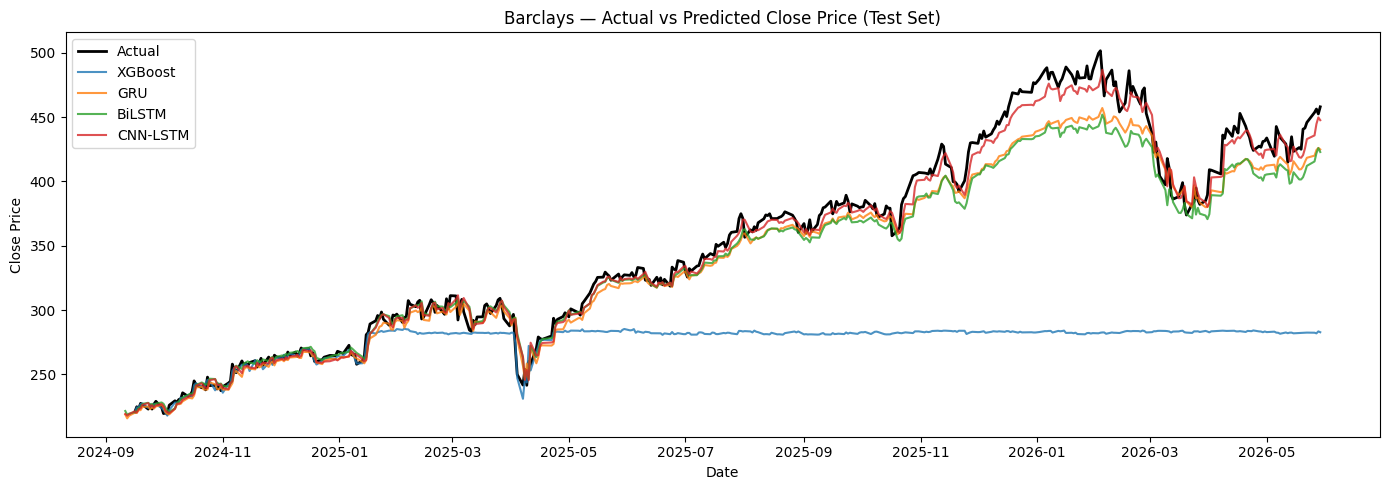

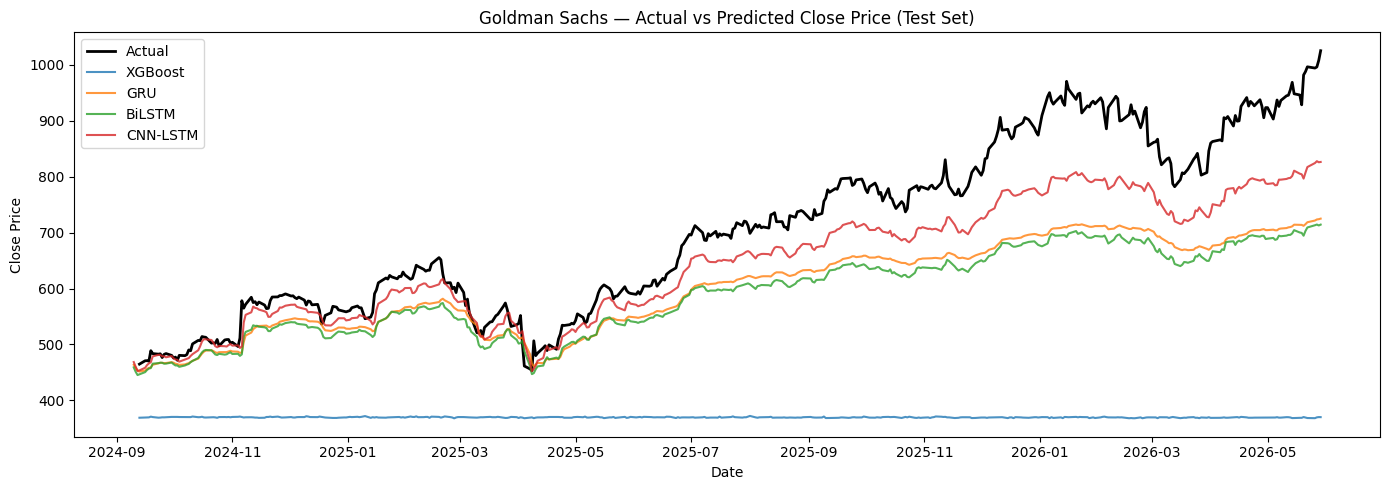

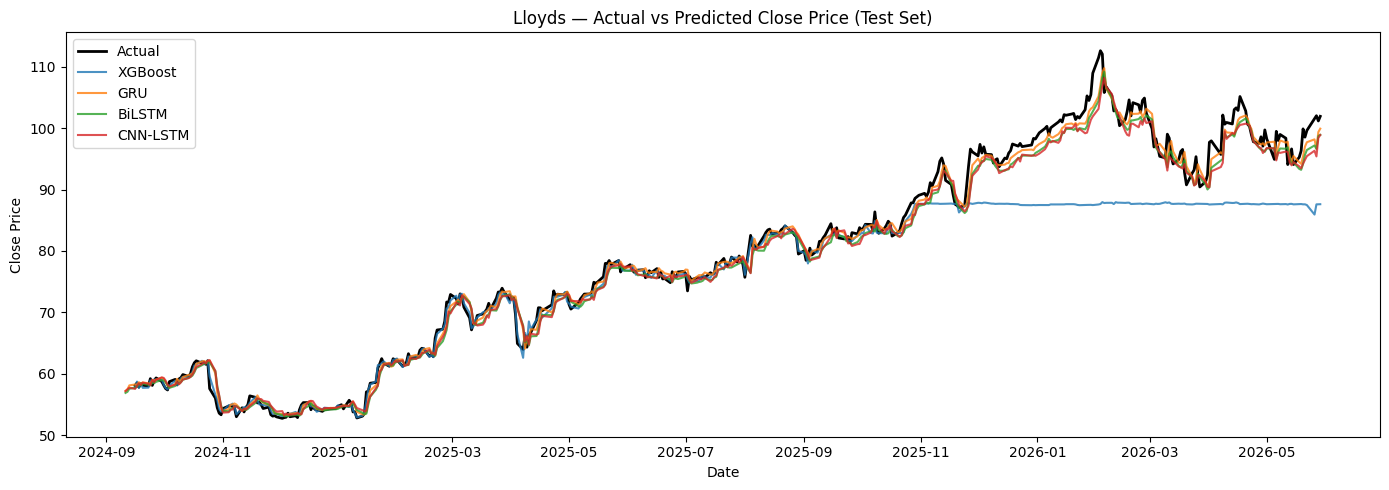

In [ ]:
for bank in BANKS:
    plt.figure(figsize=(14, 5))
    first = True
    for model_name, res in results[bank].items():
        if first:
            plt.plot(res["dates"], res["y_true"], label="Actual", color="black", linewidth=2)
            first = False
        plt.plot(res["dates"], res["y_pred"], label=model_name, alpha=0.8)
    plt.title(f"{bank} — Actual vs Predicted Close Price (Test Set)")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.tight_layout(); plt.show()

### RMSE Comparison Chart

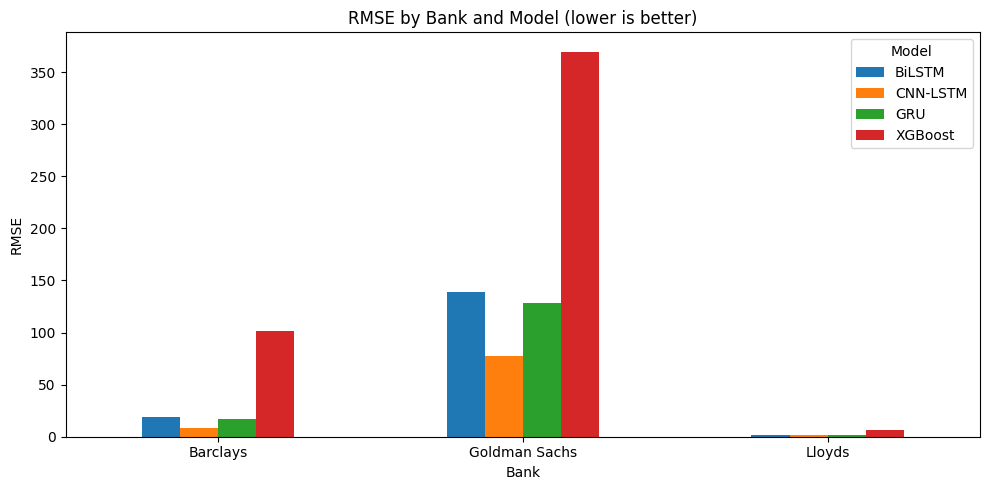

In [ ]:
pivot = summary_df.pivot(index="Bank", columns="Model", values="RMSE")
pivot.plot(kind="bar", figsize=(10, 5))
plt.title("RMSE by Bank and Model (lower is better)")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## Save Trained Models

- XGBoost → .json
- GRU / BiLSTM / CNN-LSTM → PyTorch .pt state dict (+ the scalers needed to
  reproduce predictions, saved as .pkl)


In [ ]:
import pickle

for bank in BANKS:
    bank_slug = bank.lower().replace(" ", "_")
    bank_dir = os.path.join(OUTPUT_DIR, bank_slug)
    os.makedirs(bank_dir, exist_ok=True)

    # XGBoost
    xgb_obj = trained_objects[bank]["XGBoost"]
    xgb_obj["model"].save_model(os.path.join(bank_dir, "xgboost_model.json"))
    with open(os.path.join(bank_dir, "xgboost_feature_columns.json"), "w") as f:
        json.dump(xgb_obj["feat_cols"], f)

    # Neural nets
    for name in ["GRU", "BiLSTM", "CNN-LSTM"]:
        obj = trained_objects[bank][name]
        fname = name.lower().replace("-", "_")
        torch.save(obj["model"].state_dict(), os.path.join(bank_dir, f"{fname}_model.pt"))
        with open(os.path.join(bank_dir, f"{fname}_scalers.pkl"), "wb") as f:
            pickle.dump({"feature_scaler": obj["feature_scaler"],
                         "target_scaler": obj["target_scaler"]}, f)

summary_df.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary.csv"), index=False)

print("Saved all models under:", OUTPUT_DIR)
for root, dirs, files in os.walk(OUTPUT_DIR):
    for fn in files:
        print(" -", os.path.join(root, fn))

Saved all models under: trained_models
 - trained_models/metrics_summary.csv
 - trained_models/barclays/cnn_lstm_scalers.pkl
 - trained_models/barclays/xgboost_feature_columns.json
 - trained_models/barclays/bilstm_model.pt
 - trained_models/barclays/gru_model.pt
 - trained_models/barclays/xgboost_model.json
 - trained_models/barclays/cnn_lstm_model.pt
 - trained_models/barclays/gru_scalers.pkl
 - trained_models/barclays/bilstm_scalers.pkl
 - trained_models/goldman_sachs/cnn_lstm_scalers.pkl
 - trained_models/goldman_sachs/xgboost_feature_columns.json
 - trained_models/goldman_sachs/bilstm_model.pt
 - trained_models/goldman_sachs/gru_model.pt
 - trained_models/goldman_sachs/xgboost_model.json
 - trained_models/goldman_sachs/cnn_lstm_model.pt
 - trained_models/goldman_sachs/gru_scalers.pkl
 - trained_models/goldman_sachs/bilstm_scalers.pkl
 - trained_models/lloyds/cnn_lstm_scalers.pkl
 - trained_models/lloyds/xgboost_feature_columns.json
 - trained_models/lloyds/bilstm_model.pt
 - train

In [ ]:
zip_path = "trained_models.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for fn in files:
            full_path = os.path.join(root, fn)
            arcname = os.path.relpath(full_path, OUTPUT_DIR)
            zf.write(full_path, arcname)

print(f"Zipped -> {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB)")

Zipped -> trained_models.zip (2447.0 KB)


In [ ]:
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print(f"Not running in Colab — find '{zip_path}' in the notebook's working "
          f"directory ({os.path.abspath(zip_path)}) and download it from the file browser.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>